In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

c:\Users\MBAhmadi\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 25.7M/25.7M [00:09<00:00, 2.82MB/s]

Extracting files...


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [21]:
imdb = pd.read_csv(r"C:\Users\MBAhmadi\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1\IMDB Dataset.csv")

In [22]:
imdb.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [23]:
imdb["review"]

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: object

# basic stats

In [24]:
word_count = imdb["review"].apply(lambda x: len(str(x).split()))
unique_word_count = imdb["review"].apply(lambda x: len(set(str(x).split())))
char_count = imdb["review"].apply(lambda x: len(str(x)))
dataset_words = imdb["review"].apply(lambda x: str(x).split())

In [25]:
np.sum(word_count.to_numpy())

11557847

In [26]:
dataset_words = dataset_words.values.tolist()

In [27]:
import numpy as np

In [28]:
len(dataset_words[0])

307

In [29]:
dataset_words = np.concatenate(dataset_words)

In [30]:
unique_words = set(dataset_words)

In [31]:
len(unique_words)

438729

In [32]:
print(np.average(word_count.to_numpy()))
print(np.std(word_count.to_numpy()))
print(np.min(word_count.to_numpy()))
print(np.argmin(word_count.to_numpy()))
print(np.max(word_count.to_numpy()))
print(np.argmax(word_count.to_numpy()))

231.15694
171.3422838351246
4
28920
2470
31481


# Most Common Words

In [33]:
words = ' '.join(imdb["review"]).split()

In [34]:
most_common = Counter(words).most_common(20)

In [35]:
most_common

[('the', 568735),
 ('a', 306960),
 ('and', 301919),
 ('of', 283625),
 ('to', 261850),
 ('is', 203056),
 ('in', 169981),
 ('I', 132498),
 ('that', 126818),
 ('this', 113726),
 ('it', 107916),
 ('/><br', 100974),
 ('was', 92658),
 ('as', 83130),
 ('with', 82569),
 ('for', 80919),
 ('The', 67317),
 ('but', 66282),
 ('on', 61197),
 ('movie', 60762)]

# Visualization

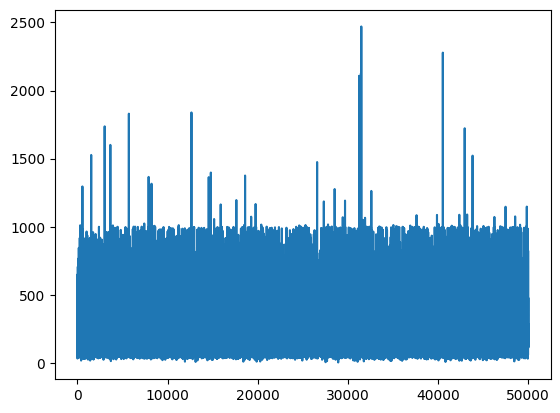

In [36]:
plt.plot(word_count.to_numpy())

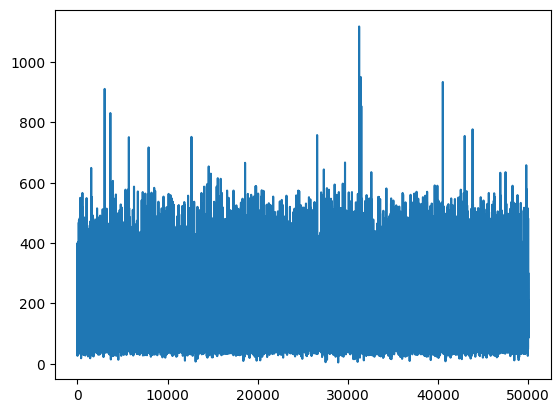

In [37]:
plt.plot(unique_word_count.to_numpy())

In [42]:
from wordcloud import WordCloud

In [43]:
text = ' '.join(imdb["review"])

In [44]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

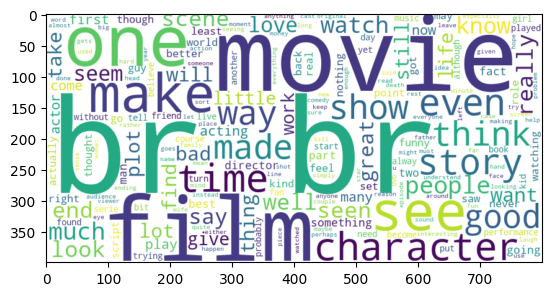

In [45]:
plt.imshow(wordcloud, interpolation='bilinear')

# TF-IDF

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [47]:
vectorizer = TfidfVectorizer(max_features=100)

In [48]:
tfidf_matrix = vectorizer.fit_transform(imdb["review"].dropna())

In [49]:
feature_names = vectorizer.get_feature_names_out()

In [50]:
tfidf_analysis = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

In [51]:
tfidf_analysis.head()

,about,after,all,also,an,and,any,are,as,at,...,well,were,what,when,which,who,will,with,would,you
0,0.052849,0.069795,0.046623,0.0,0.048409,0.174585,0.0,0.089633,0.162851,0.000000,...,0.061977,0.0,0.108242,0.000000,0.062157,0.101276,0.0,0.191665,0.059856,0.135146
1,0.072491,0.000000,0.127902,0.0,0.000000,0.279385,0.0,0.122947,0.000000,0.000000,...,0.255034,0.0,0.000000,0.000000,0.085259,0.000000,0.0,0.157741,0.000000,0.061792
2,0.000000,0.000000,0.000000,0.0,0.000000,0.199201,0.0,0.076703,0.000000,0.080211,...,0.106072,0.0,0.000000,0.097364,0.000000,0.000000,0.0,0.131214,0.000000,0.000000
3,0.000000,0.000000,0.244084,0.0,0.000000,0.203112,0.0,0.156419,0.142096,0.000000,...,0.108155,0.0,0.000000,0.099275,0.108470,0.000000,0.0,0.200685,0.000000,0.157229
4,0.107460,0.000000,0.094800,0.0,0.000000,0.147912,0.0,0.045564,0.041391,0.000000,...,0.000000,0.0,0.055023,0.000000,0.063193,0.000000,0.0,0.038972,0.000000,0.000000


N-gram

In [54]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import nltk

In [55]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MBAhmadi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [56]:
text = ' '.join(imdb["review"])

In [57]:
tokens = word_tokenize(text)

In [58]:
n_grams = list(ngrams(tokens, 2))

In [60]:
Counter(n_grams).most_common(10)

[(('<', 'br'), 201948),
 (('br', '/'), 201948),
 (('/', '>'), 201948),
 (('>', '<'), 101021),
 (('of', 'the'), 75037),
 ((',', 'and'), 58500),
 (('.', 'The'), 52832),
 (('in', 'the'), 46170),
 (('.', 'I'), 44407),
 ((',', 'but'), 41646)]

# News Categories

In [61]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

100%|██████████| 26.5M/26.5M [00:33<00:00, 837kB/s] 

Extracting files...


Path to dataset files: C:\Users\MBAhmadi\.cache\kagglehub\datasets\rmisra\news-category-dataset\versions\3


In [63]:
import json

In [65]:
with open(r"C:\Users\MBAhmadi\.cache\kagglehub\datasets\rmisra\news-category-dataset\versions\3\News_Category_Dataset_v3.json", 'r') as f:
    data = f.read()

In [66]:
short_descriptions = []

In [69]:
# Open and read the file
with open(r"C:\Users\MBAhmadi\.cache\kagglehub\datasets\rmisra\news-category-dataset\versions\3\News_Category_Dataset_v3.json", 'r', encoding='utf-8') as f:
    data_raw = f.readlines()  # This reads all lines into a list

In [70]:
for element in data_raw:
  data_text = json.loads(element.replace("\n",""))['short_description']
  short_descriptions.append(data_text)

In [71]:
short_descriptions[:10]

['Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.',
 "He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to the U.S. attorney's office in Los Angeles.",
 '"Until you have a dog you don\'t understand what could be eaten."',
 '"Accidentally put grown-up toothpaste on my toddler’s toothbrush and he screamed like I was cleaning his teeth with a Carolina Reaper dipped in Tabasco sauce."',
 'Amy Cooper accused investment firm Franklin Templeton of unfairly firing her and branding her a racist after video of the Central Park encounter went viral.',
 'The 63-year-old woman was seen working at the South Carolina store on Thursday. She was found dead Monday after her family reported her missing, authorities said.',
 '"Who\'s that behind you?" an anchor for New York’s PIX11 asked journalist Michelle Ross as she finished up an int

# basic stats

In [72]:
News_Category = pd.DataFrame(short_descriptions, columns=["short_descriptions"])

In [73]:
News_Category

,short_descriptions
0,Health experts said it is too early to predict...
1,He was subdued by passengers and crew when he ...
2,"""Until you have a dog you don't understand wha..."
3,"""Accidentally put grown-up toothpaste on my to..."
4,Amy Cooper accused investment firm Franklin Te...
...,...
209522,Verizon Wireless and AT&T are already promotin...
209523,"Afterward, Azarenka, more effusive with the pr..."
209524,"Leading up to Super Bowl XLVI, the most talked..."
209525,CORRECTION: An earlier version of this story i...


In [74]:
word_count = News_Category["short_descriptions"].apply(lambda x: len(str(x).split()))
unique_word_count = News_Category["short_descriptions"].apply(lambda x: len(set(str(x).split())))
char_count = News_Category["short_descriptions"].apply(lambda x: len(str(x)))
dataset_words = News_Category["short_descriptions"].apply(lambda x: str(x).split())

In [75]:
np.sum(word_count.to_numpy())

4121192

In [76]:
dataset_words = dataset_words.values.tolist()

In [77]:
import numpy as np

In [78]:
len(dataset_words[0])

29

In [79]:
dataset_words = np.concatenate(dataset_words)

In [80]:
unique_words = set(dataset_words)

In [81]:
len(unique_words)

214349

In [82]:
print(np.average(word_count.to_numpy()))
print(np.std(word_count.to_numpy()))
print(np.min(word_count.to_numpy()))
print(np.argmin(word_count.to_numpy()))
print(np.max(word_count.to_numpy()))
print(np.argmax(word_count.to_numpy()))

19.66902594892305
14.152749634226527
0
20773
243
66816


# Most Common Words

In [83]:
words = ' '.join(News_Category["short_descriptions"]).split()

In [84]:
most_common = Counter(words).most_common(20)

In [85]:
most_common

[('the', 174011),
 ('to', 115624),
 ('of', 98699),
 ('a', 98175),
 ('and', 92628),
 ('in', 61228),
 ('is', 48152),
 ('that', 41983),
 ('for', 37878),
 ('The', 33946),
 ('I', 31433),
 ('on', 29874),
 ('you', 27870),
 ('are', 26374),
 ('with', 25908),
 ('be', 21584),
 ('it', 20505),
 ('have', 20278),
 ('was', 18742),
 ('as', 18321)]

# Visualization

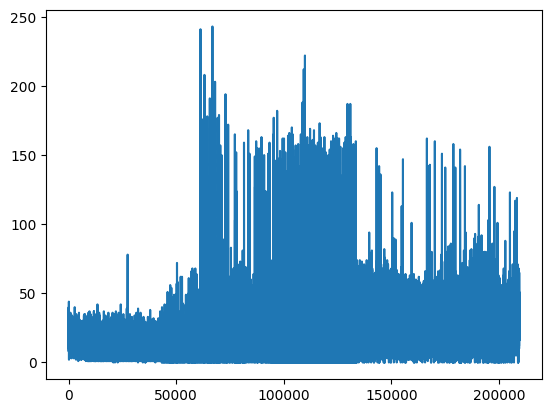

In [86]:
plt.plot(word_count.to_numpy())

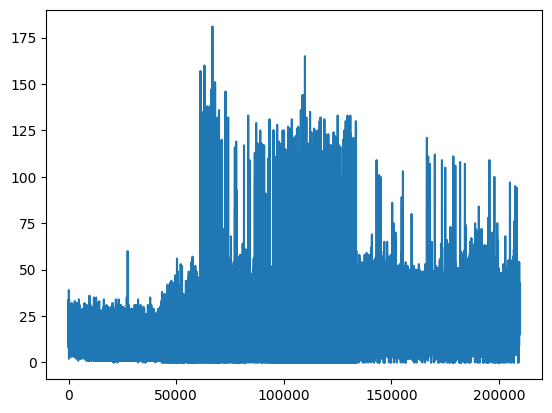

In [87]:
plt.plot(unique_word_count.to_numpy())

In [88]:
from wordcloud import WordCloud

In [89]:
text = ' '.join(News_Category["short_descriptions"])

In [90]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

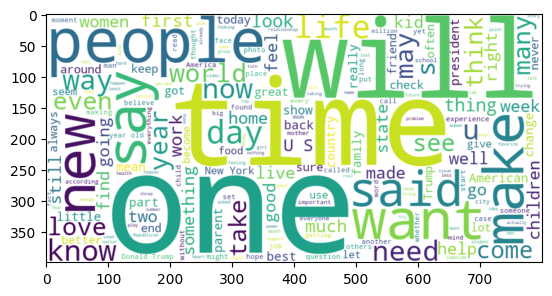

In [91]:
plt.imshow(wordcloud, interpolation='bilinear')

# TF-IDF

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [93]:
vectorizer = TfidfVectorizer(max_features=100)

In [94]:
tfidf_matrix = vectorizer.fit_transform(News_Category["short_descriptions"].dropna())

In [95]:
feature_names = vectorizer.get_feature_names_out()

In [96]:
tfidf_analysis = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

In [97]:
tfidf_analysis.head()

,about,after,all,an,and,are,as,at,be,been,...,when,who,will,with,world,would,year,years,you,your
0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.00000,0.0,0.0,0.252076,0.0,0.375951,0.0,0.0,0.000000,0.0
1,0.0,0.321073,0.0,0.0,0.148040,0.0,0.0,0.0,0.000000,0.0,...,0.27718,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
2,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.335396,0.0,...,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.628664,0.0
3,0.0,0.000000,0.0,0.0,0.186213,0.0,0.0,0.0,0.000000,0.0,...,0.00000,0.0,0.0,0.279059,0.0,0.000000,0.0,0.0,0.000000,0.0
4,0.0,0.411858,0.0,0.0,0.189899,0.0,0.0,0.0,0.000000,0.0,...,0.00000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0


N-gram

In [98]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import nltk

In [99]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MBAhmadi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [100]:
text = ' '.join(News_Category["short_descriptions"])

In [101]:
tokens = word_tokenize(text)

In [102]:
n_grams = list(ngrams(tokens, 2))

In [103]:
Counter(n_grams).most_common(10)

[(('.', 'The'), 21234),
 (('of', 'the'), 18290),
 (('in', 'the'), 15035),
 ((',', 'and'), 13689),
 (('.', "''"), 12992),
 ((',', 'the'), 9545),
 (('.', '``'), 9273),
 ((',', 'but'), 9176),
 (('.', 'I'), 8480),
 (('.', 'It'), 8105)]